Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from scipy.stats.mstats import winsorize

from scipy.stats import pearsonr
from scipy.stats import spearmanr

from sklearn.decomposition import PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

Cell 2 — Load Dataset

In [2]:
info = pd.read_csv(
    "/kaggle/input/datasets/mexwell/open-university-learning-analytics/studentInfo.csv"
)

assessment = pd.read_csv(
    "/kaggle/input/datasets/mexwell/open-university-learning-analytics/studentAssessment.csv"
)

vle = pd.read_csv(
    "/kaggle/input/datasets/mexwell/open-university-learning-analytics/studentVle.csv"
)

In [3]:
engagement = (
    vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

engagement.rename(
    columns={
        "sum_click": "engagement"
    },
    inplace=True
)

engagement.head()

,id_student,engagement
0,6516,2791
1,8462,656
2,11391,934
3,23629,161
4,23698,910


In [4]:
assessment_score = (
    assessment
    .groupby("id_student")["score"]
    .mean()
    .reset_index()
)

assessment_score.rename(
    columns={
        "score": "assessment"
    },
    inplace=True
)

assessment_score.head()

,id_student,assessment
0,6516,61.800000
1,8462,87.000000
2,11391,82.000000
3,23629,82.500000
4,23698,74.444444


In [5]:
performance = info[
    [
        "id_student",
        "final_result"
    ]
].copy()
mapping = {
    "Distinction":100,
    "Pass":75,
    "Fail":25,
    "Withdrawn":0
}

performance["performance"] = (
    performance["final_result"]
    .map(mapping)
)

performance = performance[
    [
        "id_student",
        "performance"
    ]
]
performance = (
    performance
    .groupby("id_student", as_index=False)
    .agg({
        "performance":"mean"
    })
)
performance.head()

,id_student,performance
0,3733,0.0
1,6516,75.0
2,8462,0.0
3,11391,75.0
4,23629,25.0


Cell 4 — Merge Features

In [6]:
academic_df = engagement.merge(
    assessment_score,
    on="id_student",
    how="inner"
)

academic_df = academic_df.merge(
    performance,
    on="id_student",
    how="inner"
)

academic_df.head()

,id_student,engagement,assessment,performance
0,6516,2791,61.800000,75.0
1,8462,656,87.000000,0.0
2,11391,934,82.000000,75.0
3,23629,161,82.500000,25.0
4,23698,910,74.444444,75.0


Cell 5 — Initial Exploration

In [7]:
print("Shape:")
print(academic_df.shape)

print()

print("Unique Students:")
print(academic_df["id_student"].nunique())

print()

print("Missing Values:")
print(academic_df.isnull().sum())

print()

print("Summary Statistics:")
print(academic_df.describe())

print("\nData Types:")
print(academic_df.dtypes)

print("\nDuplicate Rows:")
print(academic_df.duplicated().sum())

academic_df.head()

Shape:
(23344, 4)

Unique Students:
23344

Missing Values:
id_student      0
engagement      0
assessment     18
performance     0
dtype: int64

Summary Statistics:
         id_student    engagement    assessment   performance
count  2.334400e+04  23344.000000  23326.000000  23344.000000
mean   7.092131e+05   1685.190413     73.154217     53.452172
std    5.555285e+05   1979.863478     15.535464     33.050482
min    6.516000e+03      1.000000      0.000000      0.000000
25%    5.048550e+05    427.000000     65.000000     25.000000
50%    5.895845e+05    994.000000     76.000000     75.000000
75%    6.451578e+05   2231.000000     84.333333     75.000000
max    2.698588e+06  28615.000000    100.000000    100.000000

Data Types:
id_student       int64
engagement       int64
assessment     float64
performance    float64
dtype: object

Duplicate Rows:
0


,id_student,engagement,assessment,performance
0,6516,2791,61.800000,75.0
1,8462,656,87.000000,0.0
2,11391,934,82.000000,75.0
3,23629,161,82.500000,25.0
4,23698,910,74.444444,75.0


## Cell 6 – Data Quality Assessment

In [8]:
print("=" * 60)
print("ACADEMIC DATA QUALITY REPORT")
print("=" * 60)

print("\nDataset Shape")
print(academic_df.shape)

print("\nUnique Students")
print(academic_df["id_student"].nunique())

print("\nMissing Values")
print(academic_df.isnull().sum())

print("\nDuplicate Rows")
print(academic_df.duplicated().sum())

print("\nData Types")
print(academic_df.dtypes)

ACADEMIC DATA QUALITY REPORT

Dataset Shape
(23344, 4)

Unique Students
23344

Missing Values
id_student      0
engagement      0
assessment     18
performance     0
dtype: int64

Duplicate Rows
0

Data Types
id_student       int64
engagement       int64
assessment     float64
performance    float64
dtype: object


Cell 7 - Missing Value Imputation

In [9]:
academic_df["assessment"] = (
    academic_df["assessment"]
    .fillna(
        academic_df["assessment"].median()
    )
)
academic_df.isnull().sum()

id_student     0
engagement     0
assessment     0
performance    0
dtype: int64

/kaggle/input/datasets/mexwell/open-university-learning-analytics/studentVle.csv

In [10]:
features = [
    "engagement",
    "assessment",
    "performance"
]

clip_limits = {}

for col in features:

    lower = academic_df[col].quantile(0.01)
    upper = academic_df[col].quantile(0.99)

    clip_limits[col] = (
        lower,
        upper
    )

    academic_df[col] = academic_df[col].clip(
        lower,
        upper
    )

Cell 9 - Verify Winsorization

In [11]:
academic_df[features].describe()

,engagement,assessment,performance
count,23344.000000,23344.000000,23344.000000
mean,1654.119046,73.274449,53.452172
std,1799.878451,14.961512,33.050482
min,29.430000,22.715000,0.000000
25%,427.000000,65.000000,25.000000
50%,994.000000,76.000000,75.000000
75%,2231.000000,84.333333,75.000000
max,9202.570000,97.333333,100.000000


In [12]:
for col in features:

    print(col)

    print(
        academic_df[col].min(),
        academic_df[col].max()
    )

    print()

engagement
29.430000000000007 9202.57

assessment
22.715000000000003 97.33333333333333

performance
0.0 100.0



Cell 10 - Standardization

In [13]:
scaler = StandardScaler()

In [14]:
academic_scaled = academic_df.copy()

academic_scaled[
    features
] = scaler.fit_transform(
    academic_df[
        features
    ]
)

In [15]:
academic_scaled.head()

,id_student,engagement,assessment,performance
0,6516,0.631657,-0.766948,0.651981
1,8462,-0.554560,0.917410,-1.617323
2,11391,-0.400102,0.583212,0.651981
3,23629,-0.829584,0.616632,-0.860889
4,23698,-0.413436,0.078202,0.651981


Cell 11 - Distribution Check

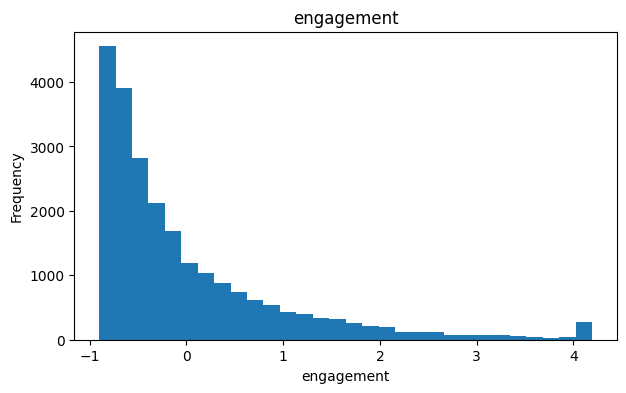

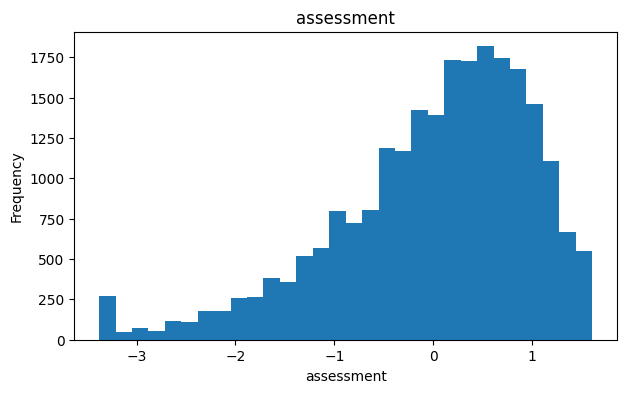

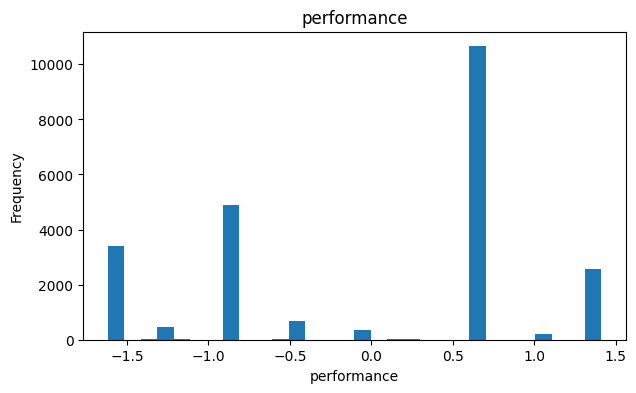

In [16]:
for col in features:

    plt.figure(figsize=(7,4))

    plt.hist(
        academic_scaled[col],
        bins=30
    )

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

Cell 12 — Save Preprocessing Objects

In [17]:

joblib.dump(
    scaler,
    "academic_scaler.pkl"
)

joblib.dump(
    clip_limits,
    "academic_clip_limits.pkl"
)

['academic_clip_limits.pkl']

Cell 13 – Pearson Correlation Analysis

In [18]:
pearson_corr = academic_scaled[
    features
].corr(method="pearson")

print("Pearson Correlation Matrix")
print()

print(pearson_corr)

Pearson Correlation Matrix

             engagement  assessment  performance
engagement     1.000000    0.290174     0.368889
assessment     0.290174    1.000000     0.455666
performance    0.368889    0.455666     1.000000


Cell 14 – Spearman Correlation Analysis

In [19]:
spearman_corr = academic_scaled[
    features
].corr(method="spearman")

print("Spearman Correlation Matrix")
print()

print(spearman_corr)

Spearman Correlation Matrix

             engagement  assessment  performance
engagement     1.000000    0.316365     0.451239
assessment     0.316365    1.000000     0.467277
performance    0.451239    0.467277     1.000000


Cell 15 – Correlation Heatmap

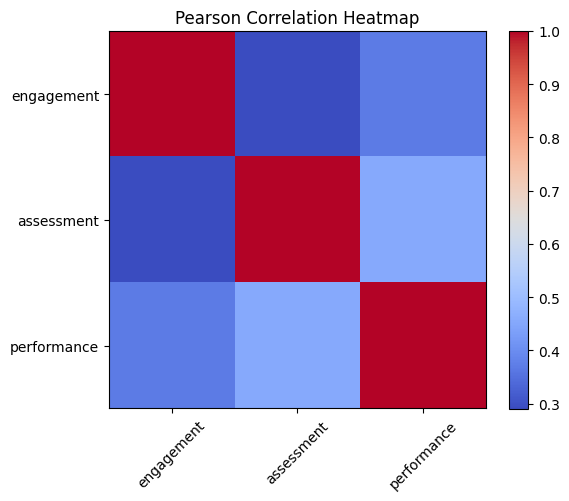

In [20]:
plt.figure(figsize=(6,5))

plt.imshow(
    pearson_corr,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(features)),
    features,
    rotation=45
)

plt.yticks(
    range(len(features)),
    features
)

plt.title("Pearson Correlation Heatmap")

plt.tight_layout()

plt.show()

Cell 16 – Multicollinearity Analysis (VIF)

In [21]:
vif_df = pd.DataFrame()

vif_df["Feature"] = features

vif_df["VIF"] = [

    variance_inflation_factor(

        academic_scaled[features].values,

        i

    )

    for i in range(len(features))

]

print(vif_df)

       Feature       VIF
0   engagement  1.183277
1   assessment  1.290129
2  performance  1.367602


Cell 17 – Principal Component Analysis

In [22]:
pca = PCA()

academic_pca = pca.fit_transform(

    academic_scaled[
        features
    ]

)

In [23]:
explained_variance = pd.DataFrame({

    "Principal Component": [

        f"PC{i+1}"

        for i in range(

            len(pca.explained_variance_ratio_)

        )

    ],

    "Explained Variance":

        pca.explained_variance_ratio_

})

print(explained_variance)

  Principal Component  Explained Variance
0                 PC1            0.582432
1                 PC2            0.240537
2                 PC3            0.177031


In [24]:
loadings = pd.DataFrame(

    pca.components_.T,

    columns=[

        f"PC{i+1}"

        for i in range(

            len(features)

        )

    ],

    index=features

)

print(loadings)

                  PC1       PC2       PC3
engagement   0.530312  0.816052 -0.229845
assessment   0.581885 -0.547515 -0.601362
performance  0.616586 -0.185166  0.765203


Cell 18 – Academic Representation

In [25]:
academic_representation = pd.DataFrame({

    "id_student":

        academic_df["id_student"],

    "Academic_PC1":

        academic_pca[:,0],

    "Academic_PC2":

        academic_pca[:,1]

})

Cell 19 – Representation Statistics

In [26]:
print()

print("Representation Shape")

print(

    academic_representation.shape

)

print()

print(

    academic_representation.describe()

)


Representation Shape
(23344, 3)

         id_student  Academic_PC1  Academic_PC2
count  2.334400e+04  23344.000000  2.334400e+04
mean   7.092131e+05      0.000000  1.704523e-17
std    5.555285e+05      1.321881  8.494946e-01
min    6.516000e+03     -3.442332 -1.782861e+00
25%    5.048550e+05     -0.967317 -6.187941e-01
50%    5.895845e+05      0.107742 -1.212371e-01
75%    6.451578e+05      0.884386  4.688160e-01
max    2.698588e+06      4.028238  5.317926e+00


Cell 20 – Academic Representation Visualization

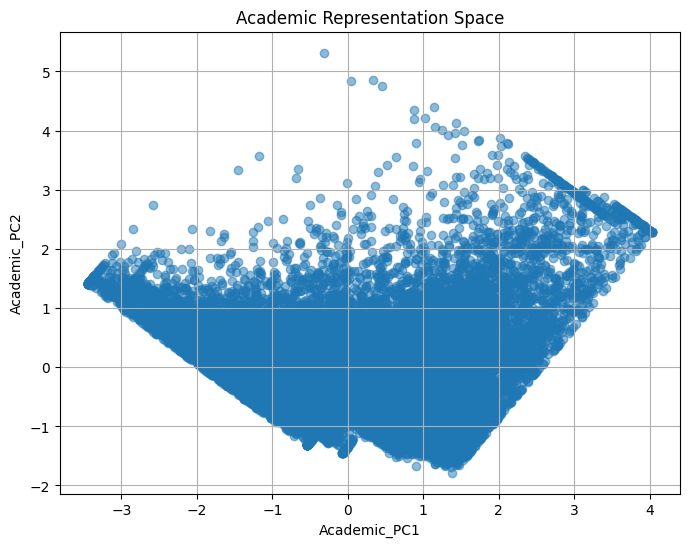

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    academic_representation["Academic_PC1"],
    academic_representation["Academic_PC2"],
    alpha=0.5
)

plt.title("Academic Representation Space")

plt.xlabel("Academic_PC1")

plt.ylabel("Academic_PC2")

plt.grid(True)

plt.show()

Cell 21 – Explained Variance

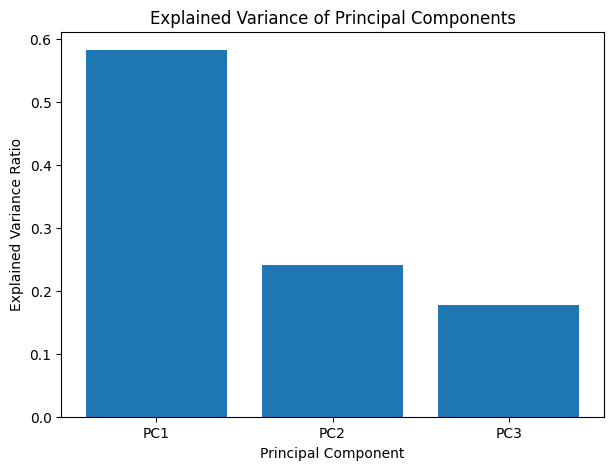

In [28]:
plt.figure(figsize=(7,5))

plt.bar(
    explained_variance["Principal Component"],
    explained_variance["Explained Variance"]
)

plt.title("Explained Variance of Principal Components")

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance Ratio")

plt.show()

Cell 22 – Cumulative Explained Variance

In [29]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

variance_df = pd.DataFrame({

    "Principal Component":[
        "PC1",
        "PC2",
        "PC3"
    ],

    "Explained Variance":
        pca.explained_variance_ratio_,

    "Cumulative Variance":
        cumulative_variance
})

print(variance_df)

  Principal Component  Explained Variance  Cumulative Variance
0                 PC1            0.582432             0.582432
1                 PC2            0.240537             0.822969
2                 PC3            0.177031             1.000000


Cell 23 – Representation Correlation

In [30]:
representation_corr = (
    academic_representation[
        [
            "Academic_PC1",
            "Academic_PC2"
        ]
    ]
    .corr()
)

print(representation_corr)

              Academic_PC1  Academic_PC2
Academic_PC1  1.000000e+00 -4.570229e-16
Academic_PC2 -4.570229e-16  1.000000e+00


Cell 24 – Validation Report

In [31]:
print("="*60)
print("ACADEMIC REPRESENTATION VALIDATION REPORT")
print("="*60)

print("\nNumber of Students:")
print(len(academic_representation))

print("\nRepresentation Shape:")
print(academic_representation.shape)

print("\nMissing Values:")
print(academic_representation.isnull().sum())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative Explained Variance:")
print(np.cumsum(
    pca.explained_variance_ratio_
))

print("\nCorrelation Between Components:")
print(
    academic_representation[
        [
            "Academic_PC1",
            "Academic_PC2"
        ]
    ].corr()
)

ACADEMIC REPRESENTATION VALIDATION REPORT

Number of Students:
23344

Representation Shape:
(23344, 3)

Missing Values:
id_student      0
Academic_PC1    0
Academic_PC2    0
dtype: int64

Explained Variance Ratio:
[0.5824319 0.2405367 0.1770314]

Cumulative Explained Variance:
[0.5824319 0.8229686 1.       ]

Correlation Between Components:
              Academic_PC1  Academic_PC2
Academic_PC1  1.000000e+00 -4.570229e-16
Academic_PC2 -4.570229e-16  1.000000e+00


Cell 25 – Save Academic Representation

In [32]:
academic_representation.to_csv(

    "academic_representation.csv",

    index=False

)

Cell 26 – Save Models

In [33]:
joblib.dump(

    scaler,

    "academic_scaler.pkl"

)

joblib.dump(

    clip_limits,

    "academic_clip_limits.pkl"

)

joblib.dump(

    pca,

    "academic_pca.pkl"

)

['academic_pca.pkl']

Cell 27 – Verify Saved Files

In [34]:
import os

files = [

    "academic_representation.csv",

    "academic_scaler.pkl",

    "academic_clip_limits.pkl",

    "academic_pca.pkl"

]

print("="*60)
print("FILES SAVED")
print("="*60)

for file in files:

    print(

        file,

        "✓"

        if os.path.exists(file)

        else "✗"

    )

FILES SAVED
academic_representation.csv ✓
academic_scaler.pkl ✓
academic_clip_limits.pkl ✓
academic_pca.pkl ✓
